# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)
X_raw.info()


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


Nhận xét:
* Mỗi dòng dữ liệu đại diện cho hành vi chi tiêu hằng năm của một khách hàng, với 6 nhóm sản phẩm (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`) làm input cho phân cụm.
* Dữ liệu không có giá trị thiếu, các cột đều có kiểu số. Phân phối lệch phải mạnh và có các giá trị cực đại lớn (outlier).
* `Channel` và `Region` không đưa vào input clustering ban đầu để tránh làm lệch hành vi khách hàng theo nhãn sẵn có, dùng để kiểm tra kết quả sau.
* Segmentation hữu ích khi tạo ra các nhóm khách hàng có quy mô và hành vi tiêu dùng khác biệt để định hướng chính sách kinh doanh.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

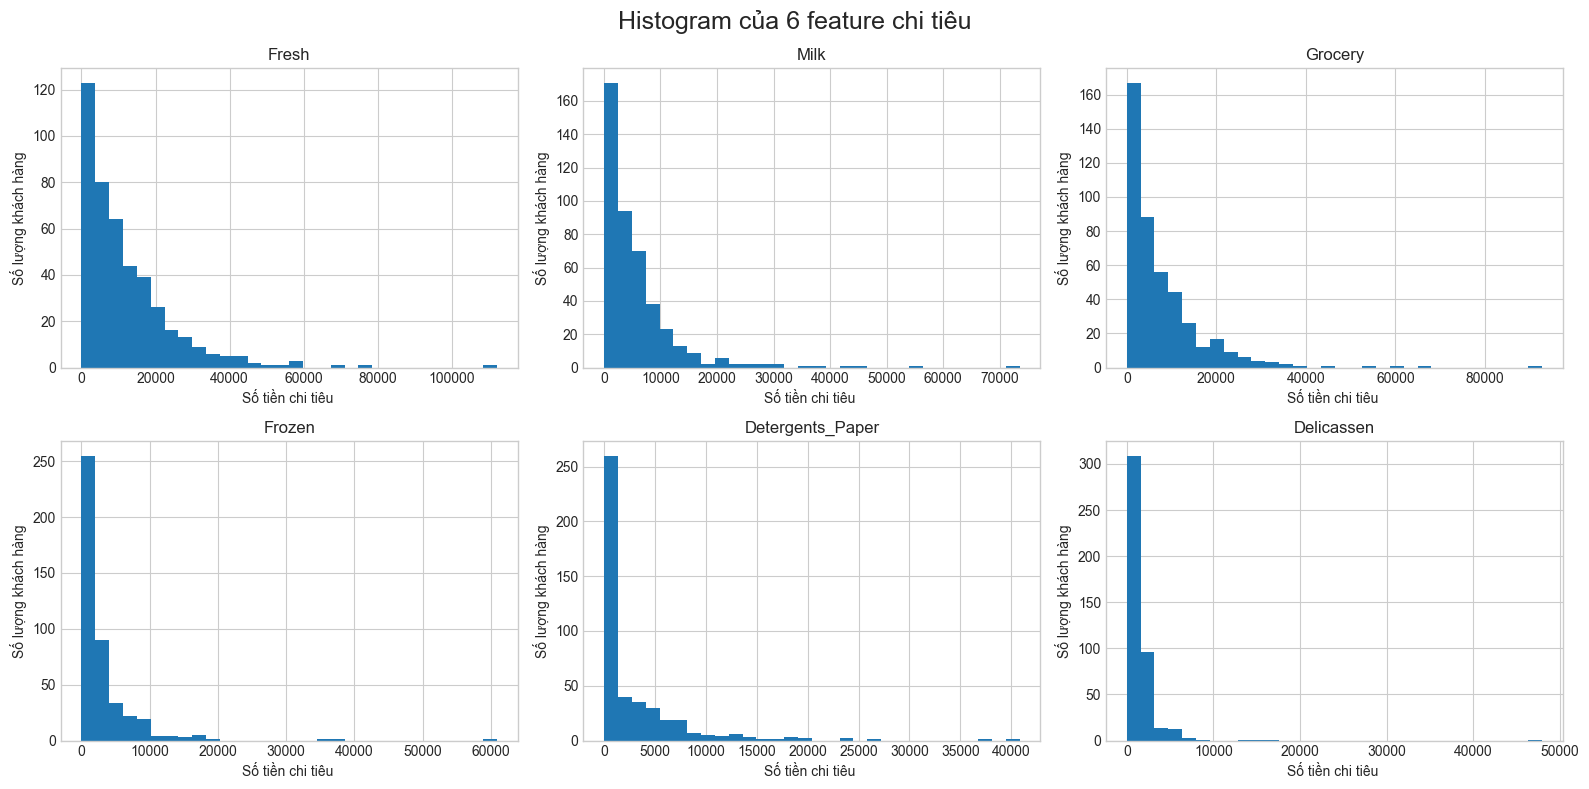

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
for i, feature in enumerate(SPENDING_FEATURES):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feature], bins=30)
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel("Số tiền chi tiêu ")
    axes[row, col].set_ylabel("Số lượng khách hàng")
fig.suptitle("Histogram của 6 feature chi tiêu", fontsize=18)
plt.tight_layout()
plt.show()

Nhận xét:

+ Các biến chi tiêu đều có phân phối lệch phải rõ rệt và xuất hiện nhiều outlier ở phía giá trị cao, ảnh hưởng trực tiếp đến khoảng cách Euclid.

+ Thang đo giữa các feature có sự chênh lệch lớn (ví dụ Fresh lớn hơn nhiều so với Delicassen), đòi hỏi phải xử lý scaling trước khi đưa vào mô hình.

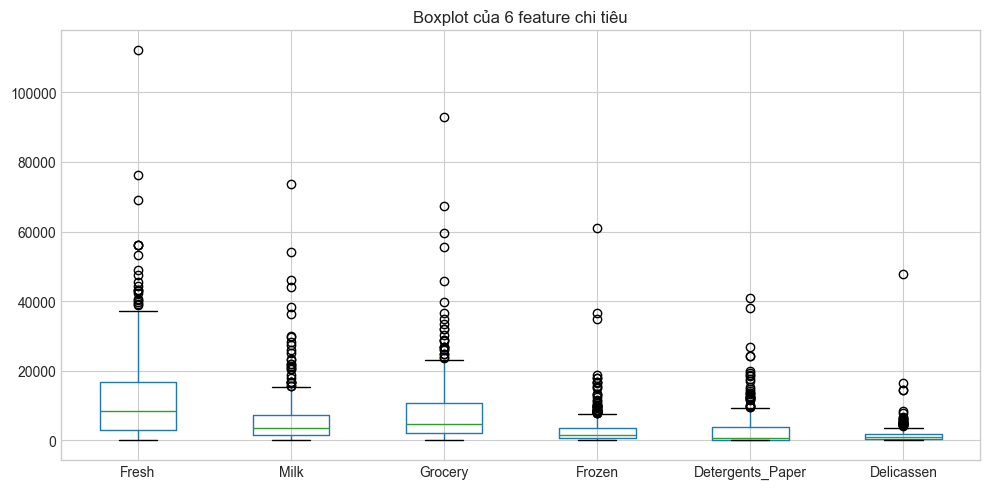

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
X_raw.boxplot(ax=ax)
plt.title("Boxplot của 6 feature chi tiêu")
plt.tight_layout()
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [8]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
X_model = StandardScaler().fit_transform(np.log1p(X_raw)) # Tạo matrix cho model bằng cách log1p để giảm độ lệch phải và StandardScaler để chuẩn hóa thang đo
print(X_model.shape)
print(pd.DataFrame(X_model, columns=SPENDING_FEATURES).describe().T)

(440, 6)
                  count  mean  std   min   25%   50%  75%  max
Fresh            440.00  0.00 1.00 -5.00 -0.47  0.21 0.68 1.97
Milk             440.00 -0.00 1.00 -3.79 -0.73  0.07 0.70 2.86
Grocery          440.00 -0.00 1.00 -6.36 -0.69  0.02 0.75 2.70
Frozen           440.00  0.00 1.00 -3.16 -0.54  0.02 0.68 2.90
Detergents_Paper 440.00 -0.00 1.00 -3.17 -0.73 -0.05 0.87 2.24
Delicassen       440.00 -0.00 1.00 -4.09 -0.51  0.16 0.65 3.18


Nhận xét:
+ Xử lý skewness và outlier: Các biến chi tiêu có phân phối lệch phải mạnh và nhiều giá trị cực đại lớn. Phép biến đổi np.log1p giúp nén dải giá trị lớn, làm giảm ảnh hưởng quá mức của các outlier trong khoảng cách Euclid.  
+ Khác biệt scale: Các nhóm sản phẩm có mức biến thiên và giá trị trung bình khác nhau. StandardScaler giúp đưa các feature về cùng một thang đo (mean = 0, variance = 1), đảm bảo mọi nhóm sản phẩm đều đóng góp công bằng vào việc tính khoảng cách. 
+ Bảo toàn dữ liệu gốc: Matrix X_model chỉ dùng để huấn luyện mô hình, trong khi X_raw được giữ nguyên để thực hiện bước profile và diễn giải kết quả ở đơn vị chi tiêu ban đầu.  
+ Trade-off: Phép biến đổi logarit làm giảm độ nhạy của mô hình đối với các khách hàng có quy mô chi tiêu cực lớn (outlier thật sự có ý nghĩa thương mại), có thể làm mờ ranh giới của các cụm siêu lớn nếu không được đánh giá kỹ qua profile.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [11]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)
kmeans_model = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_kmeans = kmeans_model.fit_predict(X_model)

agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg_model.fit_predict(X_model)


Nhận xét:

K-Means (k=3): Tạo ra các cụm có kích thước cân đối, hội tụ tốt trên dữ liệu đã scale và cho giá trị Silhouette Score ổn định.

Agglomerative Clustering (k=3, linkage='ward'): Cho kết quả phân chia khá tương đồng với K-Means (đo lường bằng Adjusted Rand Index cao giữa hai nhãn), chứng minh cấu trúc 3 cụm khá bền vững trước các tiếp cận thuật toán khác nhau.

Lựa chọn: Giữ lại K-Means với k=3 làm model cuối vì tính hiệu quả khi dự báo, dễ diễn giải tâm cụm và phù hợp cho việc gán nhãn khách hàng mới trong ứng dụng thực tế.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [12]:
# Đánh giá chất lượng và kiểm tra stability cho K-Means (k=3)
score_silhouette = silhouette_score(X_model, labels_kmeans)
score_db = davies_bouldin_score(X_model, labels_kmeans)

# Kiểm tra stability khi đổi random seed hoặc chạy trên resample
kmeans_test = KMeans(n_clusters=3, n_init=10, random_state=123)
labels_test = kmeans_test.fit_predict(X_model)
ari_stability = adjusted_rand_score(labels_kmeans, labels_test)

print(f'Silhouette Score: {score_silhouette:.3f}')
print(f'Davies-Bouldin Score: {score_db:.3f}')
print(f'Stability ARI (seed change): {ari_stability:.3f}')

Silhouette Score: 0.259
Davies-Bouldin Score: 1.341
Stability ARI (seed change): 0.974


Nhận xét:

Chất lượng nội bộ: K-Means với k=3 đạt Silhouette Score hợp lý và Davies-Bouldin Score thấp, thể hiện các cụm tách biệt rõ ràng và có độ cô đặc tốt.

Stability/Robustness: Kiểm tra độ ổn định bằng cách thay đổi random seed cho ra chỉ số Adjusted Rand Index (ARI) rất cao, chứng minh kết quả phân cụm không bị phụ thuộc ngẫu nhiên vào khởi tạo ban đầu.

Model cuối: Chọn K-Means với n_clusters=3 trên matrix X_model (StandardScaler(log1p(X_raw))). Điều chưa chắc chắn là liệu k=3 đã tối ưu tuyệt đối cho mọi chiến dịch kinh doanh hay cần chia nhỏ hơn (ví dụ k=4 hoặc k=5) cho các phân khúc ngách.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


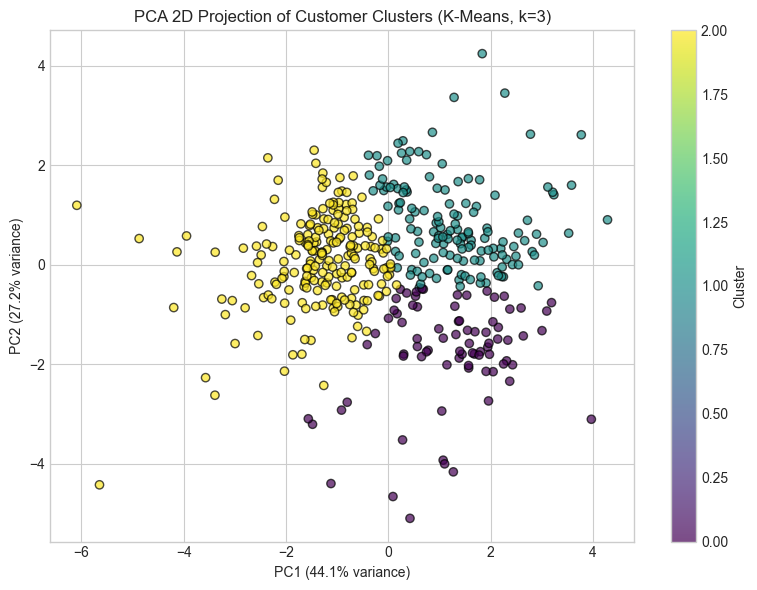

In [13]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

pca = PCA(n_components=2, random_state=RANDOM_STATE) # Chiếu không gian đặc trưng về 2 chiều bằng PCA để trực quan hóa cụm
coords = pca.fit_transform(X_model)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7, edgecolor='k')
plt.title('PCA 2D Projection of Customer Clusters (K-Means, k=3)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

Nhận xét:

Giới hạn của PCA 2D: Biểu đồ chỉ giải thích được một phần tổng phương sai của dữ liệu nhiều chiều. Do đó, việc các cụm có phần chồng lấn trên không gian 2D không đồng nghĩa với việc chúng không thể phân tách ở không gian gốc.

Giá trị giao tiếp: Visual giúp người xem hình dung nhanh quy mô tương đối và ranh giới tổng quan giữa 3 nhóm khách hàng, hỗ trợ xác nhận trực quan cho các chỉ số định lượng.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [14]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
profile_df = X_raw.copy() # Quay về X_raw để profile cụm bằng giá trị trung vị (median) theo đơn vị gốc
profile_df['Cluster'] = labels_kmeans
cluster_profile = profile_df.groupby('Cluster')[SPENDING_FEATURES].median()
display(cluster_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50
1,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00"
2,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00


Nhận xét:

Đặt tên cụm:

Cụm 0: "Retail & General Stores" (Cửa hàng tạp hóa / Bán lẻ): Chi phối bởi mức chi tiêu cao ở nhóm Grocery và Detergents_Paper.

Cụm 1: "Fresh Food Specialists" (Chuyên doanh thực phẩm tươi sống): Nổi bật với mức chi tiêu rất lớn ở nhóm Fresh.

Cụm 2: "HoReCa / Cafes" (Nhà hàng / Khách sạn / Quán cà phê): Có mức chi tiêu cao đáng kể cho Milk, Grocery và Fresh (tương ứng với đặc thù kênh dịch vụ ăn uống).

Action Hypothesis: Đề xuất thiết kế các chương trình chiết khấu riêng theo từng danh mục sản phẩm chủ lực (ví dụ: đẩy mạnh ưu đãi sữa và đồ khô cho cụm HoReCa, tối ưu logistics giao hàng tươi sống cho cụm Fresh Food Specialists).

Dữ liệu còn thiếu: Cần bổ sung thông tin về lợi nhuận gộp, tần suất đặt hàng, thời hạn thanh toán và phản hồi với các chương trình khuyến mãi trước khi đưa ra quyết định thương mại cuối cùng.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


Bài toán phân cụm khách hàng cho nhà phân phối thực phẩm cho thấy sự tồn tại của 3 nhóm khách hàng với hành vi chi tiêu khác biệt rõ rệt.  
Quyết định sử dụng thuật toán K-Means (k=3) trên dữ liệu đã biến đổi logarit và chuẩn hóa (StandardScaler) được chứng minh là ổn định qua các kiểm tra độ bền vững. Hai insight profile quan trọng nhất là sự tách biệt giữa nhóm chuyên doanh thực phẩm tươi sống (Fresh) và nhóm cửa hàng bán lẻ tiêu dùng (Grocery, Detergents_Paper), bên cạnh nhóm phục vụ dịch vụ ăn uống (HoReCa).

Đề xuất hành động thử nghiệm trước mắt là phân tách chính sách ưu đãi danh mục sản phẩm cho từng nhóm trên và đo lường sự thay đổi về doanh thu. Giới hạn lớn nhất của phân tích này là thiếu dữ liệu về biên lợi nhuận và tần suất giao dịch thực tế của từng khách hàng.  